# Pràctica 1: Resolem un problema de classificació

## Objectius

Els objectius d’aquesta pràctica són:

* Aplicar els coneixements adquirits sobre classificació, tècniques d’emplenament de valors perduts i validació creuada.

* Comparar diferents models de classificació.

* Realitzar la cerca d’hiperparàmetres.

* Entendre i implementar la validació creuada.

* Analitzar detalladament els resultats obtinguts durant l’entrenament dels diferents models.

Aquesta pràctica és prèvia al cas Kaggle que realitzareu durant la segona part de l’assignatura. En aquesta primera fase les preguntes estan definides, però us ha de servir d’aprenentatge per saber com estructurar un projecte d’aprenentatge automàtic, ja que en el cas Kaggle no tindreu les preguntes pautades.

## Bases de dades
En aquesta pràctica farem servir la base de dades del *Titanic*. L’atribut a predir és *Survived*, que indica si cada passatger va sobreviure o no.

[Enllaç a les dades](https://www.kaggle.com/c/titanic/data)

## Treball en grup

La pràctica es durà a terme en grups de 2 o 3 persones. En casos excepcionals i degudament justificats, es podrà realitzar de manera individual.

Joan Aguilar - 1704680

Javier Emparan - 1704634

Gerard Benet - 1704125

## Seguiment i entrega de la pràctica

A la Pràctica 1 es proposen diverses tasques per fer una comparació adequada dels resultats obtinguts amb diferents mètodes de classificació aplicats a una mateixa base de dades.

Es realitzaran sessions de seguiment del treball, orientades a resoldre dubtes sobre les dades, aclarir els objectius de cada apartat de l’enunciat i comentar els resultats obtinguts durant l’anàlisi. És molt recomanable assistir-hi amb el treball ja avançat per tal de poder aprofitar millor la sessió.

Pel que fa a l’entrega, caldrà lliurar a través de Caronte el següent:

1. *Memòria* en format PDF o en la mateixa notebook, explicant els resultats obtinguts sobre la base de dades i incloent el codi en Python corresponent. Aquesta nota serà la mateixa per a tots els membres del grup. (9 punts)

2. *Presentació* amb els resultats (màxim 4 minuts). Aquesta nota serà individual. (1 punt)

*Nota*: En cas d’entregar la memòria en format PDF, cal adjuntar el codi en Python per separat. Si s’entrega en format notebook, aquest mateix document ja servirà com a codi.


# Continguts que s’avaluaran en la pràctica

1. **EDA (Exploratory Data Analysis)** – 1 punt

* Anàlisi de la mida i tipologia de les dades (0.25 pts)

* Primera valoració de correlacions (0.5 pts)

* Anàlisi de l’atribut target (0.25 pts)

2. **Preprocessament** – 2 punts

* Eliminació de valors nuls (0.5 pts)

* Codificació de variables categòriques (0.75 pts)

* Altres (PCA, normalització, etc.) (0.75 pts)

3. **Selecció de mètriques** – 1.5 punts

* Selecció de la mètrica més adequada pel problema (0.75 pts)

* Visualització de corbes ROC/AUC (0.75 pts)

4. **Selecció de models amb validació creuada** – 4 punts

* Selecció del millor model (2 pts)

* Cerca d’hiperparàmetres (2 pts)

5. **Anàlisi final** – 1.5 punts

Cal tenir en compte que les puntuacions dins de cada apartat són orientatives. La pràctica està estructurada a partir d’un seguit de preguntes guia en cada secció, relacionades amb els continguts avaluables. **No cal respondre-les totes**: el seu objectiu és ajudar-vos a reflexionar i aprofundir en els aspectes clau de cada apartat. Tot i així, és recomanable llegir-les prèviament i tenir-les en compte durant el desenvolupament de la pràctica.

**IMPORTANT**: El criteri principal d’avaluació serà la capacitat de mantenir una narrativa coherent a mesura que es presenten els resultats. No es penalitzarà deixar alguna pregunta sense respondre, sempre que el procés seguit i les conclusions extretes a partir dels resultats siguin consistents i ben fonamentats.

### 1. EDA (*Exploratory Data Analysis*) – **1 punt**

Abans de començar, és fonamental analitzar la base de dades assignada.  

**Preguntes:**  
-  1.Quants atributs té la base de dades?  

Té un total de 12 atributs: PassengerID, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin i Embarked.

-  2.Quin tipus d’atributs hi ha? (numèrics, temporals, categòrics, binaris, ...)  

PassengerID (Categòric), Survived (Binari), Pclass (Categòric), Name (Textual), Sex (Binari), Age (Numèric), SibSp (Numèric), Parch (Numèric), Ticket (Categòric),Fare (Numèric), Cabin (Categòric), Embarked (Categòric)

-  3.Com és el *target*? Quantes categories diferents té?  

L'atribut target és l'atribut “Survived”, que és de tipus binari i, conseqüentment, té dos possibles valors:
0 si no va sobreviure i 1 si va sobreviure.

-  4.Hi ha valors nuls (*NaNs*) a les dades?  

Sí, hi han alguns, concretament en les columnes Age, Cabin i Embarked. Es pot veure veient els counts dels diferents camps.

-  5.Es poden observar correlacions entre les variables explicatives (*X*) i la variable objectiu (*y*)? 

Sí. Per mostrar-ho hem fet el codi d'aquí sota. Es pot comprovar observant com la mitjana d'algunes categories, com el sexe o el cost, és molt diferent entre els dos sub-dataframes.

-  6.Les etiquetes estan balancejades? (és a dir, hi ha una distribució similar entre categories?). Creus que la seva distribució pot afectar la classificació? 

Això es pot saber relacionant les medianes amb les mitjanes d'algunes variables no categòriques i mirant els valors dels quartils. Podem veure que algunes variables, com els preus, no ho estan, i això pot afectar bastant la classificació i predicció de l'atribut objectiu.

In [2]:
#Llibreries
import pandas as pd
from pandas.api.types import is_numeric_dtype
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder
from sklearn.metrics import accuracy_score, mean_absolute_error, classification_report, f1_score, accuracy_score, precision_recall_curve, auc, roc_curve, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import seaborn as sns
import time


from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import GridSearchCV, HalvingGridSearchCV


In [3]:
#1-Cantitat de atributs. (quants atributs té la base de dades?)
train = pd.read_csv('train.csv')

print("Nombre d'atributs:", len(train.columns))


Nombre d'atributs: 12


In [4]:
#1.5 (Correlacions entre les variables explicatives)
train = pd.read_csv('train.csv')
print("Print inicial:")
print(train.describe(include='all'))

numeric_features = train.select_dtypes(np.number).keys()
non_numeric = [k for k in train.keys() if k not in numeric_features]

for col in non_numeric:
    train[col] = LabelEncoder().fit_transform(train[col])

target = 'Survived'
trains = train[train[target] == 1]
trainn = train[train[target] == 0]

print(f"\n\nAll data: {train.describe()}\n")
print(f"({target}): {trains.describe()}\n")
print(f"(Not {target}): {trainn.describe()}\n")

threshold = 0.5
correlation_categories = []
print(f"Likely correlationed to ({target}):")
for c in train.columns:
    if(abs(1-(trains[c].mean()/trainn[c].mean())) > threshold and c != target):
        correlation_categories.append(c)

print(correlation_categories)

Print inicial:
        PassengerId    Survived      Pclass                     Name   Sex  \
count    891.000000  891.000000  891.000000                      891   891   
unique          NaN         NaN         NaN                      891     2   
top             NaN         NaN         NaN  Braund, Mr. Owen Harris  male   
freq            NaN         NaN         NaN                        1   577   
mean     446.000000    0.383838    2.308642                      NaN   NaN   
std      257.353842    0.486592    0.836071                      NaN   NaN   
min        1.000000    0.000000    1.000000                      NaN   NaN   
25%      223.500000    0.000000    2.000000                      NaN   NaN   
50%      446.000000    0.000000    3.000000                      NaN   NaN   
75%      668.500000    1.000000    3.000000                      NaN   NaN   
max      891.000000    1.000000    3.000000                      NaN   NaN   

               Age       SibSp       Parch  Tick

C:\Users\aguil\AppData\Local\Temp\ipykernel_42304\779206197.py:24: RuntimeWarning: divide by zero encountered in scalar divide
  if(abs(1-(trains[c].mean()/trainn[c].mean())) > threshold and c != target):


### 2. Preprocessament (*normalització, tractament d’outliers, selecció de variables...*) – **2 punts**

Un cop conegudes les dades disponibles, cal preparar-les per als algoritmes d’aprenentatge. Segons la tipologia de dades, es poden filtrar atributs, aplicar reductors de dimensionalitat, codificar categories textuals en valors numèrics, normalitzar, o bé detectar i eliminar outliers.

Consulteu la documentació de scikit-learn sobre preprocessament per explorar les diferents opcions que ofereix.

Preguntes:

- Les dades estan normalitzades? Caldria fer-ho?

No, no estan normalitzades (escales completament diferents). Sí que és necessari normalitzar-les, per a utilitzar les dades numèriques sense que els valors més elevats ofusquin els valors més petits. En aquest cas, caldria normalitzar fare i age, ja que són les úniques variables numèriques del dataset.

- En cas de normalitzar, quin tipus de normalització seria més adient per a les vostres dades?

Hi ha 3 formes de normalitzar les dades: StandardScaler (distribució normal), MinMaxScaler (rang de dades [0-1]) i RobustScaler (per treballar amb valors de diferents dimensions). Utilitzarem RobustScaler ja que és el tipus de normalització que deixa els valors més equitatius, com es pot comprovar amb el codi d'aquí sota.

- Hi ha moltes dades sense informació (NaNs)? Tingueu en compte que alguns mètodes no les toleren durant l’aprenentatge.

Com hem vist en l'exercici 1, podem trobar més de 200 valors NaNs en la columna d'edats, i alguns en Cabin i Embarked.

- Com afecta la classificació si les filtreu?

Perdríem una quarta part de les dades, el que comportaria molts altres problemes com una pèrdua en la precisió del model.

- I si les reompliu? Com ho faríeu?

Mantendríem totes les mostres de dades. Per omplir els NaNs, podríem utilitzar la mediana de les variables numèriques (per reduir l'impacte dels outliers) i la moda/valors més freqüent per a les categòriques.

- Hi ha dades categòriques? Quina seria la codificació més adequada?

Si, com hem vist a l'exercici 1, hi han dades categòriques, com poden ser PClass, sex, etc. Aquestes poden ser codificades de diferents maneres, ajustant-se al que signifiquen. Per exemple la categoria sex, es podria utilitzar un labelEncoder, on male=0 i female=1. La PClass ja està codificada en nombres, per tant, no fa falta fer cap canvi. 
Per contra, hi han altres dades que optarem per eliminar ja que seran difícils de codificar i no aporten res, com els noms, o que tenen una correlació alta amb altres, com Cabin, que té una correlació molt alta amb Pclass.

- Es poden extreure atributs addicionals a partir de les variables categòriques (per exemple, aplicant alguna regla sobre el text)?

Sí, es podria extreure informació. Per exemple, es podria considerar el nombre de cabines que ha comprat cada passatger, fent la longitud del split del camp. També es podría classificar en funció de la localització de les cabines en el vaixell.

- Caldria aplicar PCA? Quins beneficis o inconvenients tindria?

Sí, es podria aplicar PCA. Es simplificaria el problema, es reduiria la dimensionalitat, el temps d'execució i, possiblement, el soroll. Tot i això, es podria perdre variància de les mostres, la qual cosa perjudicaria la seva clusterització i, per tant, la precisió dels algoritmes. En aquest cas, no l'aplicarem, ja que considerem que no hi ha prous camps perquè compensi realitzar una simplificació.

- Seria útil aplicar alguna tècnica de selecció de features? Ho trobeu necessari?

Sí, es podria aplicar alguna tècnica de selecció de features i pot ser útil per saber quines categories són més importants. Per una banda, podem escollir o descartar manualment categories, com poden ser Nom i PassengerID, ja que aquestes no aporten cap informació útil. 
Una tècnica automàtica pot ser el SequencialFeature Selector. Va afegint categories fins a arribar a un punt on no augmenta més, només agafant les categories que han millorat els resultats. En aquest problema, hem decidit no utilitzar cap selector ja que tampoc hi han tantes categories. Això si, descartarem algunes manualment, com ara el Nom i el PassengerID. També descartarem Cabin i Ticket ja que creiem que el primer camp té un percentatge massa alt de Nans per garantir bons resultats, i el segon un rang massa gran de valors únics. Això es pot veure al primer describe del exercici anterior.

- Es podrien aplicar PolynomialFeatures per millorar la classificació? En quins models tindria sentit fer-ho?

Sí, l'aplicació de PolynomialFeatures pot millorar la classificació, però només en models lineals com Regressió logistica, ja que PolynomialFeatures permet a aquest tipus de models a capturar relacions no lineals i interaccions entre variables que no podria veure. Altres models com SVM, Random Forest i Gradient Boosting ja aconsegueixen capturar aquestes relacions per si mateixos, per tant l'us de PolynomialFeatures no milloraría la classificació.

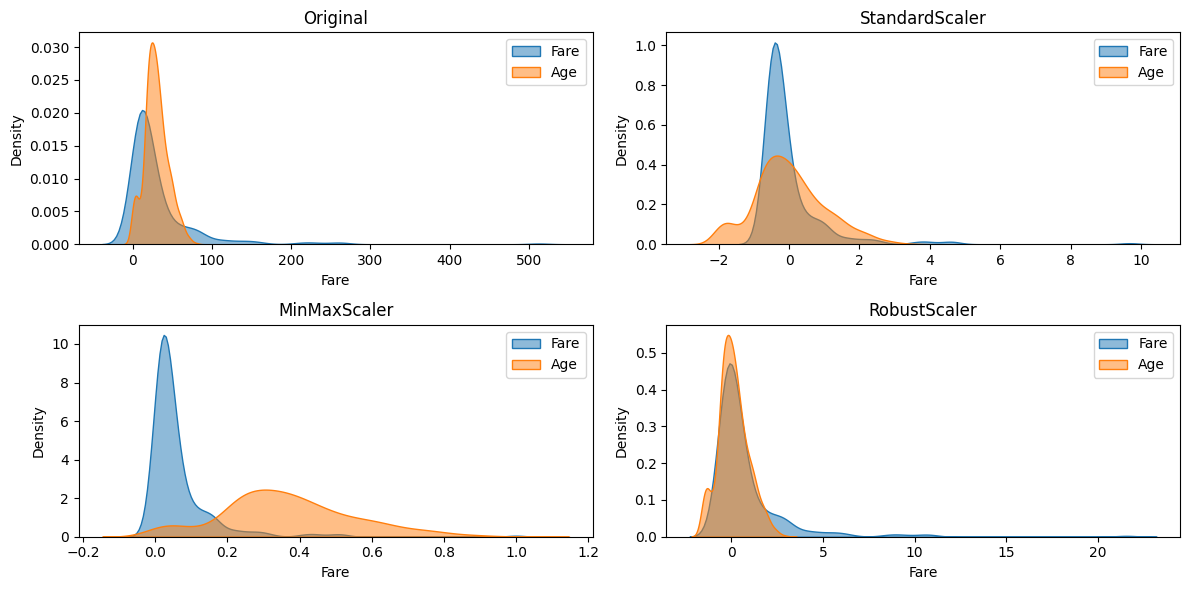

In [5]:
#Comparación de diferentes técnicas de normalización y estandarización
# Cargamos el dataset del Titanic
titanic = pd.read_csv("train.csv")

# Variables numericas con rangos muy diferentes
data = titanic[['Age', 'Fare']]

# Escaladores
scalers = {
    "Original": data,
    "StandardScaler": pd.DataFrame(StandardScaler().fit_transform(data), columns=data.columns),
    "MinMaxScaler": pd.DataFrame(MinMaxScaler().fit_transform(data), columns=data.columns),
    "RobustScaler": pd.DataFrame(RobustScaler().fit_transform(data), columns=data.columns),
}

# Visualización comparativa
plt.figure(figsize=(12, 6))

for i, (name, scaled) in enumerate(scalers.items(), 1):
    plt.subplot(2, 2, i)
    sns.kdeplot(scaled['Fare'], fill=True, label='Fare', alpha=0.5)
    sns.kdeplot(scaled['Age'], fill=True, label='Age', alpha=0.5)
    plt.title(name)
    plt.legend()

plt.tight_layout()
plt.show()

### 3. Selecció de mètriques – **1.5 punts**

En aquest apartat ens centrarem en les mètriques de classificació ([documentació](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics)).  

Per començar, entreneu una **regressió logística** (no cal separar *train-test*). A partir d’aquesta, genereu una sèrie de funcions per analitzar els resultats. Aquestes funcions serviran més endavant.  

També caldrà triar la mètrica que farem servir posteriorment per escollir el millor model.  

**Preguntes:**  
-  A teoria hem vist el comportament de l’`accuracy_score` en dades no balancejades. Quina de les següents mètriques creieu que és més adequada pel vostre problema? Justifiqueu-ho.  
   - `accuracy_score`: No molt efectiva per a casos on les classes estan desbalancejades, al predir la classe major.  
   - `f1_score`: Combina la precisió i el recall en un sol valor, equilibrant falsos positius i negatius.
   - `average_precision_score`: Útil quan la classe positiva és molt minoritària. (<10%)

   En el nostre cas, la decisió la tenim entre l'f1_score i l'average_precision_score, ja que la base de dades està desbalancejada. Cal mirar si la classe minoritària és molt més petita (codi que trobem en la següent cel·la). Com és aproximadament un 40%, no és tan petit com per fer servir l'average_precision_score. Per tant, utilitzarem l'f1_score.

-  Abans d’entrenar models, genereu una suite de funcions per analitzar gràficament el rendiment.  
   -  Mostreu la *Precision-Recall Curve* i la *ROC Curve*.  
   -  Quina és més rellevant per al vostre dataset? 

   La més rellevant per al nostre dataset és la Precision-Recall Curve.

-  Expliqueu amb les vostres paraules la diferència entre ambdues. [Pista](https://stats.stackexchange.com/questions/338826/auprc-vs-auc-roc)

      La diferència principal entre la ROC Curve i la Precision-Recall Curve és el seu enfocament i la seva sensibilitat al desequilibri de classes:

      - ROC: Mostra la relació entre la Taxa de Veritables Positius (TPR) i la Taxa de Falsos Positius (FPR), avaluant la capacitat global del model per distingir entre classes. Tot i això, quan la classe positiva és minoritària, la FPR pot ser molt baixa simplement per la gran quantitat de negatius, fent que la corba sembli millor del que realment és.

      - Precision-Recall: Mostra la relació entre la precisió i el recall, centrant-se en el rendiment de la classe positiva. És més informativa quan la classe positiva és minoritària, ja que reflecteix millor com el model detecta correctament els positius i evita falsos positius.


-  Què mostra el [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)?  
   Mostra, per cada classe:
      - Precision: Proporció de prediccions positives correctes sobre totes les prediccions positives.
      - Recall: Proporció de positius reals detectats correctament pel model.
      - F1-score: Mitjana harmònica entre la precisió i el recall, equilibrant falsos positius i falsos negatius.
      - Support: Nombre d’exemples reals de cada classe.

-  Quina mètrica triareu per optimitzar la classificació en el vostre cas?  
   La mètrica que triem és l’F1-score de la classe positiva (Survived = 1), ja que combina la precisió i el recall en un sol valor, equilibrant els falsos positius i els falsos negatius.
   Segons el classification_report, la classe positiva té un F1-score de 0.90, fet que mostra un bon equilibri entre detectar correctament els supervivents i evitar falses prediccions.




> **Nota:** En aquest apartat **no es valoren els resultats obtinguts**. El que s’avalua és:  
> - L’elecció raonada de la mètrica de classificació.  
> - Saber quines gràfiques cal generar per analitzar els resultats.  
>   
> Recordeu: abans de solucionar un problema cal tenir molt clara la mètrica d’error que s’utilitzarà, i aquesta decisió s’ha de prendre **abans d’entrenar models**.  


In [6]:
# Mirem si la clase minoritaria es molt més petita que la majoritària
train = pd.read_csv('train.csv')

count_survived = train['Survived'].value_counts()
print("Distribució de la variable 'Survived':")
print(count_survived)



Distribució de la variable 'Survived':
Survived
0    549
1    342
Name: count, dtype: int64


Per fer la nostra regressió logíca cal primer omplir els Nans:

In [7]:
# Importació de llibreries necessàries
# Llegim el fitxer CSV

# Funciones explicadas en clase para el tratamiento de Nans (del fichero de ejemplo)
def get_cols_with_na(df):
  isna = df.isna().sum().sort_values()
  isna = isna[isna>0]
  cols = isna.index
  return cols

def add_binary_nan_columns(df,remove_duplicates = True):
  cols_with_nan = get_cols_with_na(df)
  for col in cols_with_nan:
    df[f'{col}_isna'] = df[col].isna()
  if remove_duplicates:
    df = df.loc[:,~df.apply(lambda x: x.duplicated(),axis=1).all()]
  return df

def fillNans(file):
  dataframe = pd.read_csv(file)
  dataframe = add_binary_nan_columns(dataframe,remove_duplicates = True)
  cols_with_nan = get_cols_with_na(dataframe)

  for col in cols_with_nan:
    if is_numeric_dtype(dataframe[col]):
      m = dataframe[col].median()
      dataframe.loc[:,col] = dataframe[col].fillna(m)
    else:
      m = dataframe[col].mode()
      dataframe.loc[:,col] = dataframe[col].fillna(m)

  return dataframe

df = pd.read_csv("train.csv")
print("Abans:")
print(df.head(30))

df = fillNans("train.csv")
print("\nDespres:")
print(df.head(30))



Abans:
    PassengerId  Survived  Pclass  \
0             1         0       3   
1             2         1       1   
2             3         1       3   
3             4         1       1   
4             5         0       3   
5             6         0       3   
6             7         0       1   
7             8         0       3   
8             9         1       3   
9            10         1       2   
10           11         1       3   
11           12         1       1   
12           13         0       3   
13           14         0       3   
14           15         0       3   
15           16         1       2   
16           17         0       3   
17           18         1       2   
18           19         0       3   
19           20         1       3   
20           21         0       2   
21           22         1       2   
22           23         1       3   
23           24         1       1   
24           25         0       3   
25           26         1      

Fem la regressió logística:

In [8]:

# Variables
X = df.drop('Survived', axis=1)
y = df['Survived']

# Convertir categóricas a numéricas
X = pd.get_dummies(X, drop_first=True)

# Entrenar modelo
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

print("Exactitud del model:", model.score(X, y))

y_pred = model.predict(X) # prediccions 0/1 (classe final)
y_pred_proba = model.predict_proba(X)[:, 1] #probabilitat de pertànyer a la classe positiva (supervivent), útil per corbes.

Exactitud del model: 0.9270482603815937


c:\Uni\titanico\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


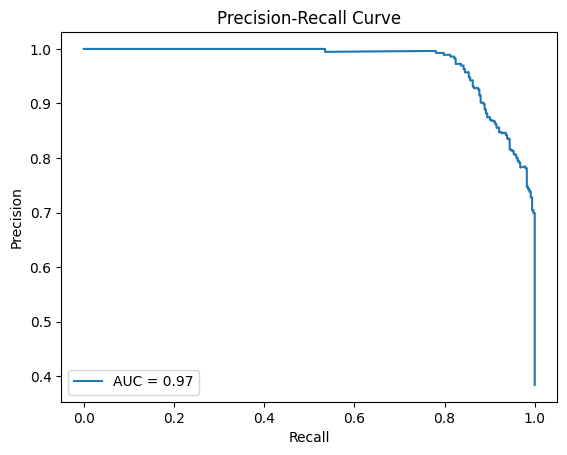

In [9]:
# Curva Precision-Recall

def plot_precision_recall(y_true, y_scores):
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    pr_auc = auc(recall, precision)
    
    plt.figure()
    plt.plot(recall, precision, label=f'AUC = {pr_auc:.2f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.show()

plot_precision_recall(y, y_pred_proba)

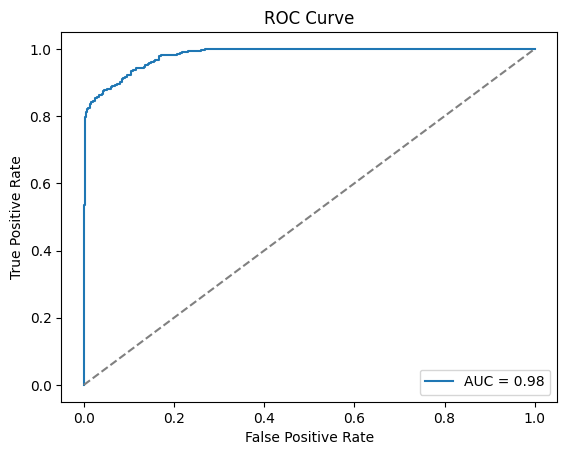

In [10]:
# Curva ROC

def plot_roc_curve(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    plt.figure()
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0,1], [0,1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()

plot_roc_curve(y, y_pred_proba)

In [11]:
# Generar el classification report
report = classification_report(y, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       549
           1       0.96      0.85      0.90       342

    accuracy                           0.93       891
   macro avg       0.94      0.91      0.92       891
weighted avg       0.93      0.93      0.93       891



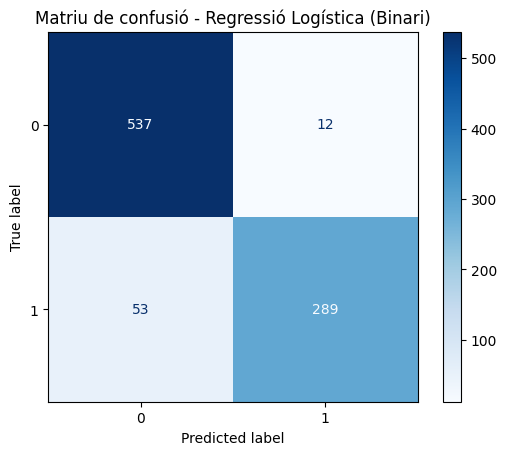

In [12]:
# Matriu de confusió
ConfusionMatrixDisplay.from_estimator(model, X, y, cmap=plt.cm.Blues)
plt.title("Matriu de confusió - Regressió Logística (Binari)")
plt.show()

### 4. Selecció de models amb validació creuada – **4 punts**

Fent servir la mètrica seleccionada a l’apartat anterior, cal escollir una sèrie de models i, mitjançant **validació creuada**, seleccionar el millor model amb els seus hiperparàmetres òptims, trobats a través d’una cerca (*hyperparameter search*).  

Aquesta tasca s’emmarca dins de l’aprenentatge computacional **supervisat**.  
A *scikit-learn* disposem de diverses tècniques ([documentació](https://scikit-learn.org/stable/supervised_learning.html)). A classe hem vist tècniques com:  
- Regressió logística  
- SVM amb diferents *kernels*  
- K-Nearest Neighbours (KNN)  
- Arbres de decisió  
- Random Forest  
- Gradient Boosting  

Per aquest apartat es demana seleccionar **un mínim de 4 models** (per exemple: regressió logística, random forest, KNN, SVM).  

**Preguntes:**  
-  Quins models heu considerat? Per què els heu seleccionat?  

Hem considerat Regressió Logística, SVM, Random Forest i Gradient Boosting. Hem triat el model de Regressió Logística, ja que és un model simple i lineal que ens pot servir com a baseline per a la resta. Després, l'SVM pot donar informació útil de l'estructura de les dades si juguem amb el kernel. A part, és un model més complex que el primer i pot arribar a demostrar resultats prometedors a causa de la mida intermèdia del dataset. Finalment, tant el Random Forest com el Gradient Boosting són exponents d'ensembles que poden ser interessants de comparar, a causa de les diferents estratègies d'assemblatge.

-  Fent servir validació creuada, escolliu el millor model (amb hiperparàmetres per defecte). 
Amb hiperparàmetres per defecte, el millor model es el Gradient Boosting.
   -  Per què és important fer servir validació creuada?  
   Per reduir el biaix que pot sorgir a la separació entre el conjunt de validació i el d'entrenament.
   -  Heu de fer servir algun [tipus específic de validació creuada](https://scikit-learn.org/stable/modules/cross_validation.html)?  
   Si, hem de fer servir algún iterador amb estratificador. En aquest cas, hem fet servir StratifiedKFold, per reduir l'impacte de la diferència de proporció entre supervivents i no supervivents. D'aquesta manera, es manté la frecuència relativa de la classe en cada fold.

-  Seleccioneu un conjunt d’**hiperparàmetres** a provar per a cada model i realitzeu la cerca corresponent. 
   
   Per a la Regressió Logística, els hiperparàmetres a provar són C (la inversa de la força de regularització) i penalty (quin tipus de regularitzador utilitza). Perquè aquests paràmetres puguin funcionar correctament, utilitzarem el solver 'saga' i assignarem un màxim d'iteracions.

   Per al SVC, utilitzarem una altra vegada C, també mirarem el Kernel, que determina la funció que separa les dades, i gamma, que ajuda quan el kernel no és lineal.

   Pel Random Forest, utilitzarem n_estimators (el nombre d'arbres del bosc), max_features (que és el nombre de característiques considerades en dividir el node) i max_depth (la profunditat màxima a la qual poden arribar els arbres).

   Per últim, al Gradient Boosting, utilitzarem n_estimators, max_depth i learning_rate, que és quant contribueix cada arbre al model.

   -  Hi ha algun model que es pugui descartar de primeres? Per què?

   Es podria descartar el regressor logístic, ja que és l'únic model estrictament lineal i que, a causa de la seva simplicitat en comparació amb els altres models, segurament no ens donarà els millors resultats. Tot i això, en aquest cas el mantenim, ja que no té molt cost computacional i pot actuar de baseline per a la resta de models.

-  Mostreu els resultats en una taula amb: model, experiments realitzats, resultats (train i test) i, opcionalment, temps d’entrenament.

   Els resultats es troben al print de sota.

-  Quin tipus de **K-fold** heu escollit per a la selecció de models i per a la selecció amb hiperparàmetres?

   Per a tots els models utilitzem un k-fold de 5, que és el default. Hem decidit no utilitzar el StratifiedKFold per dues raons. La primera és que el temps en l'SVC es disparava i, en segon lloc, GridSearchCV ja fa internament un StratifiedKFold, a més d'altres optimitzacions que no fa si li passem nosaltres el StratifiedKFold.

-  Com afecta el nombre de folds al resultat final?  

   El nombre de k-folds varia el temps i score dels models. Un k-fold menor dona el resultat més rapid, però les dades agafades per al entrenament són més susceptibles a no reflexar la capacitat predictiva del model de forma tan precisa.
   
-  Quines formes de buscar el millor paràmetre heu trobat?  

   Hem contemplat la Grid Search per trobar els millors hiperparàmetres, ja que és una forma simple i molt utilitzada de provar diferents valors i combinacions d'hiperparàmetres, i és molt més còmode que la cerca manual per a models amb diversos paràmetres. També hem trobat el Halving Search, una funció experimental de sklearn que actua de manera similar al Grid Search, però tallant els pitjors models abans. Finalment, també hem considerat la cerca aleatòria, que prova valors aleatòriament.

   -  Són costoses computacionalment?  
   -  [Documentació *Grid Search*](https://scikit-learn.org/stable/modules/grid_search.html)  
   
   Bastant. La més lleugera (a part de la manual) sería la del halving, després la aleatòria i finalment la exhaustiva, que té un cost computacional força alt.
   -  Quina heu seleccionat?  
   
   Hem seleccionat la cerca exhaustiva o Grid Search, ja que era la que donava millors resultats tot i ser més cara. També hem provat amb el Halving Search i molts més valors, però els resultats eren bastant pitjors i per això l'hem descartat. Quant a l'aleatòria, no ens convencia el poc determinisme i la variabilitat potencial dels resultats.
-  Si disposem de recursos limitats (per exemple, un PC durant 1 hora), quin mètode creieu que donarà millor resultat final?

   El més probable és que el model sigui el Gradient Boosting, ja que és el que ha donat millors resultats en totes les proves. La regressió logística acostuma a tenir un rendiment pitjor en problemes no lineals. L'SVM és un model que es veu molt limitat pel seu alt cost computacional i no és l'òptim quan els recursos són limitats. El dubte estaria llavors entre el Random Forest i el Gradient Boosting i, entre aquests dos, el Gradient Boosting sol retornar millors resultats, ja que aprèn contínuament a través de les iteracions internes, afinant-se millor. Amb els recursos suficients, però, creiem que l'SVM podria superar-lo.

-  Existeixen mètodes de cerca més eficients? ([scikit-optimize](https://scikit-optimize.github.io/stable/))

Si que existeixen. Un exemple d'això és la optimització bayesiana. Aquesta aprèn una funció que relaciona els hiperparàmetres amb el resultat, el que permet estimar millors hiperparàmetres de forma més intel·ligent i ràpida.

In [ ]:
#Treiem els Nans
df = fillNans("train.csv")

#Escalem els camps numèrics
scaler = RobustScaler()
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

#Dividim el dataset entre X i y
y = df[target]
X = df.drop(columns=[target, "Name", "Ticket", "Cabin", "PassengerId"])

#Passem els atributs categòrics a numèrics
X = pd.get_dummies(X, columns=['Sex', 'Embarked'], drop_first=True)

trainX, testX, trainy, testy = train_test_split(X, y, test_size=0.2, random_state=42)

#Fent servir validació creuada, escolliu el millor model (amb hiperparàmetres per defecte).  
models = {
    "Regressió Logística": LogisticRegression(random_state=42, max_iter=1000),
    "SVC": SVC(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, trainX, trainy, cv=kfold, scoring='f1_macro')
    results[name] = {
        'mean_f1': cv_scores.mean(),
        'std_f1': cv_scores.std()
    }

    model.fit(trainX, trainy)
    preds = model.predict(testX)
    test_f1 = f1_score(testy, preds, average='macro')
    test_acc = accuracy_score(testy, preds)

    print(f"- {name}: F1-Score Mitjà train = {cv_scores.mean():.4f} (std = {cv_scores.std():.4f}) F1-Score test = {test_acc:.4f}")

- Regressió Logística: F1-Score Mitjà train = 0.7761 (std = 0.0212) F1-Score test = 0.8212
- SVM: F1-Score Mitjà train = 0.7990 (std = 0.0325) F1-Score test = 0.8101
- Random Forest: F1-Score Mitjà train = 0.7941 (std = 0.0287) F1-Score test = 0.8156
- Gradient Boosting: F1-Score Mitjà train = 0.7998 (std = 0.0124) F1-Score test = 0.8101


In [24]:
#escollim els hiperparametres que utilitzarem al grid search
models = {
   "Regressió Logística": (
        LogisticRegression(random_state=42, max_iter=10000, solver='saga'),
        {
            'C': [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 1, 2, 3, 5, 10, 20, 50, 100],
            'penalty': ['l1', 'l2']
        }
    ),

   "SVC": (
        SVC(random_state=42),
        {
            'C': [0.1, 0.5, 1, 3, 7, 10, 12],
            'kernel': ['linear', 'rbf', 'poly'],
            'gamma': ['scale', 0.1, 0.2]
        }
    ),

    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {
            'n_estimators': [100, 200, 300, 400, 500, 700, 1000],
            'max_depth': [5, 10, 15, 20, 30, 40, None],
            'max_features': ['sqrt', 'log2']
        }
    ),

    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=42),
        {
            'n_estimators': [100, 200, 300, 400, 500, 700, 1000],
            'learning_rate': [0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.15, 0.2],
            'max_depth': [2, 3, 4, 5, 6]
        }
    )
}

for nom, (model,parametres) in models.items():
    inici = time.time()
    print(f"{nom}: \nEs comprovaràn els següents hiperparàmetres: \n{parametres} \n")
    grid = GridSearchCV(estimator=model, param_grid=parametres, cv=5, scoring='f1_macro', n_jobs=-1)
    grid.fit(trainX, trainy)
    print(f"La millor puntuació F1 ha sigut: {grid.best_score_:.4f} amb el model {grid.best_params_} i ha trigat {time.time() - inici:.2f} segons")

    preds = grid.best_estimator_.predict(testX)
    test_f1 = f1_score(testy, preds, average='macro')
    test_acc = accuracy_score(testy, preds)
    print(f"La puntuació F1 del test ha sigut: {test_acc:.4f}\n")


Regressió Logística: 
Es comprovaràn els següents hiperparàmetres: 
{'C': [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 1, 2, 3, 5, 10, 20, 50, 100], 'penalty': ['l1', 'l2']} 

La millor puntuació F1 ha sigut: 0.7780 amb el model {'C': 0.7, 'penalty': 'l1'} i ha trigat 3.30 segons
La puntuació F1 del test ha sigut: 0.8156

SVC: 
Es comprovaràn els següents hiperparàmetres: 
{'C': [0.1, 0.5, 1, 3, 7, 10, 12], 'kernel': ['linear', 'rbf', 'poly'], 'gamma': ['scale', 0.1, 0.2]} 

La millor puntuació F1 ha sigut: 0.8066 amb el model {'C': 7, 'gamma': 'scale', 'kernel': 'rbf'} i ha trigat 0.50 segons
La puntuació F1 del test ha sigut: 0.8156

Random Forest: 
Es comprovaràn els següents hiperparàmetres: 
{'n_estimators': [100, 200, 300, 400, 500, 700, 1000], 'max_depth': [5, 10, 15, 20, 30, 40, None], 'max_features': ['sqrt', 'log2']} 

La millor puntuació F1 ha sigut: 0.8021 amb el model {'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 400} i ha trigat 13.21 segons
La puntuació F1 del test ha sig

### 5. Anàlisi final – **1.5 punts**

Un cop seleccionat el millor model amb els hiperparàmetres òptims, cal elaborar un **report final** amb els resultats obtinguts.  

Considerem que el millor model és el Gradient Boosting. Aquest és el que ha donat millors resultats tant en els models per defecte com en els tunejats. Encara que pot semblar que el procés de Grid Search ha sigut bastant més llarg que la resta, cal destacar que és el model en el que s'han provat més combinacions d'hiperparàmetres, de manera que aquesta mètrica tampoc és tan reveladora. Hem descartat la regresió logística pels seus pitjors resultats, i el svc per la seva alta complexitat computacional i el seu llarg temps de configuració. Encara que no ho haguem deixat a la versió final, hem descobert que si provàvem el valor C = 5 o afegiem uns quants valors més als paràmetres, el temps es disparava de manera exagerada, passant de la mitja hora. Finalment, hem descartat el Random Forest ja que el Gradient Boosting aprèn contínuament a través de les iteracions internes, afinant-se millor i retornant millors resultats.

**Preguntes:**  
-  Mostreu les corbes ROC/PR (la que hàgiu escollit a l’apartat 3) i interpreteu els resultats.

Al principi (amb un recall baix), la precisió és molt alta (pròxima a 1), cosa que indica que els primers casos que el model classifica com a positius són gairebé tots correctes. A mesura que augmenta el recall, el model intenta detectar més positius reals, però això també comporta un increment dels falsos positius, fet que redueix gradualment la precisió. Quan el recall arriba al màxim (1.0), la precisió baixa fins a valors al voltant de 0.4, ja que el model classifica com a positius molts exemples negatius per tal d’identificar tots els positius possibles.

L’àrea sota la corba (AUC = 0.84) indica un bon equilibri entre precisió i recall, i suggereix que el model té un bon rendiment general per a la detecció de la classe Survived.

-  Analitzeu en detall les diferents mètriques que considereu adients.  
  - Després d'entrenar i avaluar quatre models, hem mesurat la seva exactitud (percentatge d'encerts) i el temps d'entrenament, com es pot veure al output de dalt. 
  
      NT. train	NT. test	T. train	T. test
  LR	0,7761	  0,8212	  0,7780	  0,8156
  SVC	0,7990	  0,8101	  0,8066	  0,8156
  RF	0,7941	  0,8156	  0,8021	  0,8212
  GB	0,7998	  0,8108	  0,8138	  0,8324
  
  Començem destacant com la exactitud de tots els models d'entrenament ha millorat després del procés de tunning. Això era esperable, encara que aquesta millora no ha sigut força destacable. 
  El Gradient Boosting és el que aconsegueix millor rendiment global, amb una exactitud lleugerament superior tant en train com en test. El Random Forest i la SVM també presenten resultats molt equilibrats i consistents. La Regressió Logística és el model més senzill, però sorprenentment manté un rendiment competitiu i fins i tot supera a la resta amb les dades de test en els models no entrenats, i empata amb la SVM amb les mateixes dades i els models entrenats.
  És estrany el com tots els tests donen millors resultats que els propis conjunts d'entrenament. Això es poc comú i podria ser el subjecte d'un futur anàlisis el esbrinar el motiu.

  Gradient Boosting:
                    precision    recall  f1-score   support

            0        0.84       0.89      0.86       105
            1        0.82       0.76      0.79        74

      accuracy                            0.83       179
    macro avg        0.83       0.82      0.82       179
  weighted avg       0.83       0.83      0.83       179

  Podem veure que la detecció dels no supervivents es bastant millor que la del valor 1 de Survived (recall de 0.89 respecte a 0.76). Això segurament es deu al desbalanç de les dades, que ha causat que el model adopti una prespectiva pessimista en les seves prediccions. Tot i això, els valors estàn força equilibrats. D'aquí podem extreure que el model és prou bo, amb un 83% de precisió.
  

-  Comentar breument com podríeu aplicar aquest model en un futur (cas d’ús).

  Aquest model podria utilitzar-se per a la millora de la seguretat dels passatgers en futurs accidents navals. Es podria optimitzar el disseny dels vaixells per a evitar falles de disseny i ubicar els recursos de salvament de manera més eficient. Per exemple, col·locant-ne més a prop de les zones on el model predigui una pitjor supervivència. També podria servir per optimitzar protocols d'evacuació, prioritzant els grups que l'algorisme identifiqui com a vulnerables en cas d'accident.

-  Quines possibles millores es podrien fer al vostre model?

Podriem fer el seguent:
  - Millorar el processament de les dades: Crear noves característiques més informatives, com la mida de la família (a partir de SibSp i Parch) o el títol del passatger (Ms, Mrs).
  - Afegir nous mètodes d'emplenament de Nans més eficients.
  - Utilitzar diversos models i combinar les seves prediccions en una sola mitjançant votacions, encara que sigui molt costós computacionalment.
  - Investigar les causes concretes d'algunes de les incògnites que hem trobat i fer més proves. Per exemple, per discernir el per què els tests tenen millor precisió que els conjunts d'entrenament. També podriem experimentar amb diferents valors de k-fold per veure com influeix en els resultats.

    

              precision    recall  f1-score   support

           0       0.84      0.89      0.86       105
           1       0.82      0.76      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



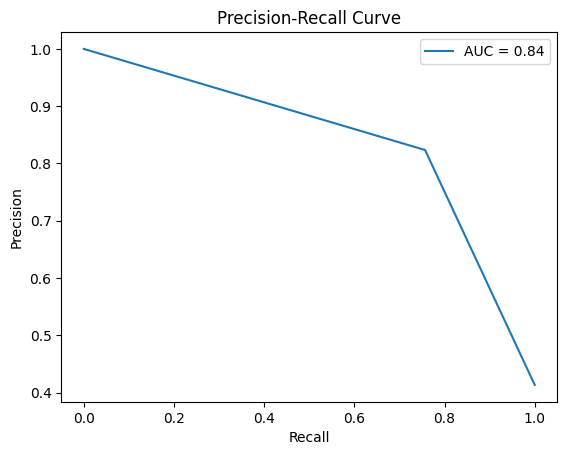

In [26]:
report = classification_report(testy, preds)
print(report)

plot_precision_recall(testy, preds)
